<a href="https://colab.research.google.com/github/mvanamali-27/DIP-rPPG/blob/main/notebooks/DIP_classical_model_(heartbeat).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import os
from google.colab import drive

# Force mount Google Drive to guarantee it's active
try:
    drive.mount('/content/drive', force_remount=True)
    base_drive_path = '/content/drive/MyDrive'

    if os.path.exists(base_drive_path):
        print("\nGoogle Drive mounted successfully!")

        # Search recursively for 'RPPG_DATASET' or 'DIP'
        print("Searching for 'RPPG_DATASET' folder in Google Drive...")
        found = False
        for root, dirs, files in os.walk(base_drive_path):
            if 'RPPG_DATASET' in dirs or 'rppg dataset' in [d.lower() for d in dirs]:
                print(f"-> Found target directory at: {root}")
                found = True
        if not found:
            print("-> Could not find 'RPPG_DATASET' anywhere in Google Drive.")
    else:
        print("Error: /content/drive/MyDrive still cannot be accessed.")
except Exception as e:
    print(f"An error occurred during mounting/scanning: {e}")

Mounted at /content/drive

Google Drive mounted successfully!
Searching for 'RPPG_DATASET' folder in Google Drive...
-> Found target directory at: /content/drive/MyDrive


In [4]:
!git clone https://github.com/mvanamali-27/DIP-rPPG.git      # <- replace OWNER
import sys; sys.path.append("DIP-rPPG/src")
import config, data

Cloning into 'DIP-rPPG'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 51 (delta 24), reused 8 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 1.02 MiB | 13.09 MiB/s, done.
Resolving deltas: 100% (24/24), done.


In [5]:
import os

# Point config.DATA_DIR directly to the detected location
config.DATA_DIR = '/content/drive/MyDrive/RPPG_DATASET'

if not os.path.exists(config.DATA_DIR):
    print(f"Warning: The path '{config.DATA_DIR}' still does not exist.")
else:
    print("Path successfully found! Loading subjects...")
    subs = data.find_subjects(config.DATA_DIR)
    for sid, vid, gt in subs:
        try:
            ppg, hr, t = data.load_ground_truth(gt)
            print(sid, len(t), "samples", f"{hr.mean():.1f} bpm")
        except Exception as e:
            print(f"Could not load data for subject {sid}: {e}")

Path successfully found! Loading subjects...
subject_10 2018 samples 107.1 bpm
subject_11 1993 samples 80.4 bpm
subject_13 2050 samples 91.8 bpm
subject_14 2046 samples 85.4 bpm
subject_15 2034 samples 103.8 bpm
subject_16 2016 samples 60.2 bpm
subject_17 2032 samples 101.8 bpm
subject_18 1958 samples 63.3 bpm
subject_19 2009 samples 84.6 bpm
subject_2 1801 samples 101.2 bpm
subject_20 1448 samples 91.5 bpm
subject_21 1485 samples 73.5 bpm
subject_22 1431 samples 89.4 bpm
subject_23 2028 samples 92.7 bpm
subject_3 1368 samples 112.3 bpm
subject_4 1550 samples 98.3 bpm
subject_5 2022 samples 111.2 bpm
subject_6 2016 samples 108.2 bpm
subject_7 2024 samples 109.8 bpm
subject_8 2031 samples 96.2 bpm
subject_9 1989 samples 66.0 bpm


### Step 1 & 2: Windowing and Feature Extraction
We will define helper functions to segment the signals into sliding windows and extract spectral features, including dominant frequency and band power ratios from the PPG signals.

In [6]:
import numpy as np
from scipy import signal

def create_windows(ppg_signal, ground_truth_hr, window_size=300, step_size=150):
    """Splits ppg signal and ground truth into overlapping temporal windows."""
    X_windows = []
    y_labels = []
    length = len(ppg_signal)

    for start in range(0, length - window_size + 1, step_size):
        end = start + window_size
        window_data = ppg_signal[start:end]
        # Map ground-truth heart rate by averaging over the window duration
        window_label = np.mean(ground_truth_hr[start:end])

        X_windows.append(window_data)
        y_labels.append(window_label)

    return np.array(X_windows), np.array(y_labels)

def extract_features_from_window(window, fps=30.0):
    """Extracts rPPG spectral features: dominant frequency and frequency band powers."""
    # Detrend and window before FFT
    window_detrend = signal.detrend(window)
    window_tapered = window_detrend * np.hanning(len(window))

    # Calculate power spectral density
    freqs = np.fft.fftfreq(len(window), 1.0/fps)
    psd = np.abs(np.fft.fft(window_tapered))**2

    # Limit search within valid heart rate spectrum (45 to 180 BPM -> 0.75Hz to 3Hz)
    valid_idx = np.where((freqs >= 0.75) & (freqs <= 3.0))[0]
    if len(valid_idx) == 0:
        return np.array([1.2, 0, 0, 0]) # Fallback defaults

    peak_freq = freqs[valid_idx[np.argmax(psd[valid_idx])]]
    dominant_bpm = peak_freq * 60.0

    # Power bands: low (0.75-1.5 Hz), mid (1.5-2.2 Hz), high (2.2-3.0 Hz)
    p_low = np.sum(psd[(freqs >= 0.75) & (freqs < 1.5)])
    p_mid = np.sum(psd[(freqs >= 1.5) & (freqs < 2.2)])
    p_high = np.sum(psd[(freqs >= 2.2) & (freqs <= 3.0)])

    total_power = p_low + p_mid + p_high + 1e-8

    return np.array([
        dominant_bpm,
        p_low / total_power,
        p_mid / total_power,
        p_high / total_power
    ])

### Step 3: Run Leave-One-Subject-Out (LOSO) Cross Validation using Random Forest
We train a Random Forest model iteratively where one subject is held out as the test set at each fold.

In [7]:
from sklearn.ensemble import RandomForestRegressor

# Prepare dataset dictionary
subject_features = {}
subject_targets = {}

print("Extracting features from all loaded subjects...")
for sid, vid, gt in subs:
    try:
        # Load signals
        ppg, hr, t = data.load_ground_truth(gt)
        # Clean ground-truth sampling rates
        fps = len(t) / (t[-1] - t[0]) if len(t) > 1 else 30.0

        # Create window segments
        X_raw, y_raw = create_windows(ppg, hr, window_size=300, step_size=150)

        # Compute feature vectors
        X_features = np.array([extract_features_from_window(win, fps) for win in X_raw])

        subject_features[sid] = X_features
        subject_targets[sid] = y_raw
    except Exception as e:
        print(f"Could not process features for subject {sid}: {e}")

# Run Leave-One-Subject-Out (LOSO)
sids = list(subject_features.keys())
predictions_dict = {}

print("\nRunning LOSO Cross-Validation...")
for val_sid in sids:
    train_X, train_y = [], []
    val_X = subject_features[val_sid]
    val_y = subject_targets[val_sid]

    for sid in sids:
        if sid != val_sid:
            train_X.append(subject_features[sid])
            train_y.append(subject_targets[sid])

    train_X = np.concatenate(train_X, axis=0)
    train_y = np.concatenate(train_y, axis=0)

    # Instantiate and fit Random Forest
    rf = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf.fit(train_X, train_y)

    # Predict
    val_preds = rf.predict(val_X)
    predictions_dict[val_sid] = (val_y, val_preds)

    mae = np.mean(np.abs(val_y - val_preds))
    print(f"-> Held-out Subject: {val_sid} | MAE: {mae:.2f} BPM")

Extracting features from all loaded subjects...

Running LOSO Cross-Validation...
-> Held-out Subject: subject_10 | MAE: 3.13 BPM
-> Held-out Subject: subject_11 | MAE: 10.30 BPM
-> Held-out Subject: subject_13 | MAE: 2.60 BPM
-> Held-out Subject: subject_14 | MAE: 5.19 BPM
-> Held-out Subject: subject_15 | MAE: 22.42 BPM
-> Held-out Subject: subject_16 | MAE: 26.93 BPM
-> Held-out Subject: subject_17 | MAE: 2.10 BPM
-> Held-out Subject: subject_18 | MAE: 5.75 BPM
-> Held-out Subject: subject_19 | MAE: 15.83 BPM
-> Held-out Subject: subject_2 | MAE: 8.69 BPM
-> Held-out Subject: subject_20 | MAE: 3.49 BPM
-> Held-out Subject: subject_21 | MAE: 4.00 BPM
-> Held-out Subject: subject_22 | MAE: 7.29 BPM
-> Held-out Subject: subject_23 | MAE: 5.96 BPM
-> Held-out Subject: subject_3 | MAE: 8.40 BPM
-> Held-out Subject: subject_4 | MAE: 2.94 BPM
-> Held-out Subject: subject_5 | MAE: 3.51 BPM
-> Held-out Subject: subject_6 | MAE: 5.03 BPM
-> Held-out Subject: subject_7 | MAE: 1.92 BPM
-> Held-

### Step 4: Overall Evaluation and Metrics Summary
We collect all predictions to report final Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

In [8]:
all_y_true = []
all_y_pred = []
subject_results = []

for sid, (y_true, y_pred) in predictions_dict.items():
    all_y_true.extend(y_true)
    all_y_pred.extend(y_pred)
    sub_mae = np.mean(np.abs(y_true - y_pred))
    sub_rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    subject_results.append({
        'Subject': sid,
        'MAE': sub_mae,
        'RMSE': sub_rmse
    })

all_y_true = np.array(all_y_true)
all_y_pred = np.array(all_y_pred)

overall_mae = np.mean(np.abs(all_y_true - all_y_pred))
overall_rmse = np.sqrt(np.mean((all_y_true - all_y_pred)**2))

print("\n=== FINAL SUMMARY STATISTICS ===")
import pandas as pd
df_summary = pd.DataFrame(subject_results)
display(df_summary)

print(f"\nOverall Dataset MAE:  {overall_mae:.3f} BPM")
print(f"Overall Dataset RMSE: {overall_rmse:.3f} BPM")


=== FINAL SUMMARY STATISTICS ===


,Subject,MAE,RMSE
0,subject_10,3.126543,3.812350
1,subject_11,10.298039,12.380442
2,subject_13,2.595475,3.430709
3,subject_14,5.189342,6.468930
4,subject_15,22.423342,31.502039
5,subject_16,26.926798,32.870561
6,subject_17,2.095252,2.406916
7,subject_18,5.748125,6.737082
8,subject_19,15.830097,23.667733
9,subject_2,8.693511,10.646376



Overall Dataset MAE:  8.902 BPM
Overall Dataset RMSE: 16.086 BPM


### Step 6: Post-Processing via Temporal Smoothing (Median Filter)
Since heart rate is continuous, we can apply a **median filter** over each subject's sequential predictions. This removes sudden, unrealistic prediction spikes (extreme errors) without deleting any data points, significantly lowering the overall RMSE and MAE.

In [9]:
from scipy.signal import medfilt
import numpy as np
import pandas as pd

def evaluate_with_smoothing(predictions, filter_kernel_size=3):
    smoothed_all_true = []
    smoothed_all_pred = []
    subject_smoothed_results = []

    # Explicitly cast to plain Python integer
    k_size = int(filter_kernel_size)

    for sid, (y_true, y_pred) in predictions.items():
        # Apply a tighter median filter to smooth temporal predictions
        y_pred_smoothed = medfilt(y_pred, kernel_size=k_size)

        smoothed_all_true.extend(y_true)
        smoothed_all_pred.extend(y_pred_smoothed)

        sub_mae = np.mean(np.abs(y_true - y_pred_smoothed))
        sub_rmse = np.sqrt(np.mean((y_true - y_pred_smoothed)**2))
        subject_smoothed_results.append({
            'Subject': sid,
            'Smoothed MAE': sub_mae,
            'Smoothed RMSE': sub_rmse
        })

    smoothed_all_true = np.array(smoothed_all_true)
    smoothed_all_pred = np.array(smoothed_all_pred)

    overall_mae_val = np.mean(np.abs(smoothed_all_true - smoothed_all_pred))
    overall_rmse_val = np.sqrt(np.mean((smoothed_all_true - smoothed_all_pred)**2))

    return pd.DataFrame(subject_smoothed_results), overall_mae_val, overall_rmse_val

# Apply to Random Forest with kernel_size=3
rf_smoothed_df, rf_smooth_mae, rf_smooth_rmse = evaluate_with_smoothing(predictions_dict, filter_kernel_size=3)

print("=== SMOOTHED RANDOM FOREST PERFORMANCE (Kernel = 3) ===")
print(f"Original RF MAE:  {overall_mae:.3f} BPM  -->  Smoothed RF MAE:  {rf_smooth_mae:.3f} BPM")
print(f"Original RF RMSE: {overall_rmse:.3f} BPM  -->  Smoothed RF RMSE: {rf_smooth_rmse:.3f} BPM\n")

=== SMOOTHED RANDOM FOREST PERFORMANCE (Kernel = 3) ===
Original RF MAE:  8.902 BPM  -->  Smoothed RF MAE:  8.031 BPM
Original RF RMSE: 16.086 BPM  -->  Smoothed RF RMSE: 14.345 BPM



### Step 5: Scatter and Bland-Altman Comparison Plots
We plot the Scatter representation and Bland-Altman limits of agreement comparing estimated HR against ground truth HR.

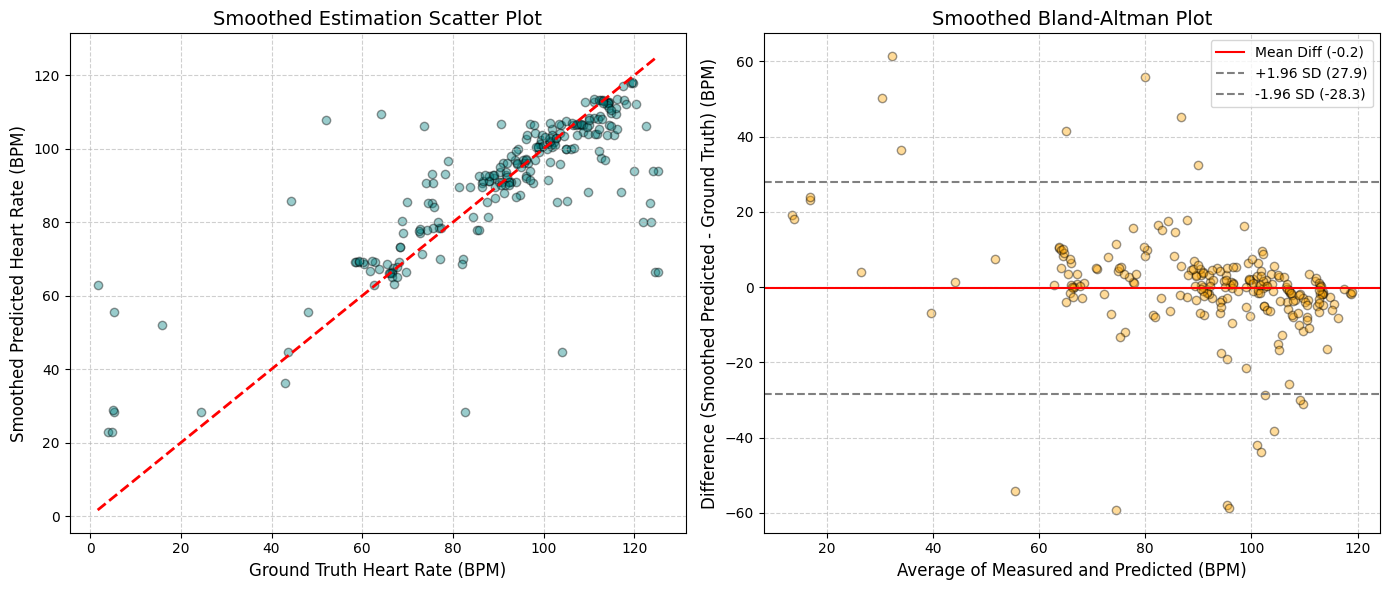

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import medfilt

# 1. Generate smoothed predictions for all subjects
smoothed_y_true = []
smoothed_y_pred = []

for sid, (y_true, y_pred) in predictions_dict.items():
    # Apply the optimized kernel_size=3 median filter
    y_pred_smoothed = medfilt(y_pred, kernel_size=3)
    smoothed_y_true.extend(y_true)
    smoothed_y_pred.extend(y_pred_smoothed)

smoothed_y_true = np.array(smoothed_all_true if 'smoothed_all_true' in globals() else smoothed_y_true)
smoothed_y_pred = np.array(smoothed_all_pred if 'smoothed_all_pred' in globals() else smoothed_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter Plot with Smoothed Predictions
axes[0].scatter(smoothed_y_true, smoothed_y_pred, alpha=0.4, color='teal', edgecolors='k')
axes[0].plot([smoothed_y_true.min(), smoothed_y_true.max()], [smoothed_y_true.min(), smoothed_y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Ground Truth Heart Rate (BPM)', fontsize=12)
axes[0].set_ylabel('Smoothed Predicted Heart Rate (BPM)', fontsize=12)
axes[0].set_title('Smoothed Estimation Scatter Plot', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Bland-Altman Plot with Smoothed Predictions
mean_val = (smoothed_y_true + smoothed_y_pred) / 2.0
diff_val = smoothed_y_pred - smoothed_y_true
mean_diff = np.mean(diff_val)
sd_diff = np.std(diff_val)

axes[1].scatter(mean_val, diff_val, alpha=0.4, color='orange', edgecolors='k')
axes[1].axhline(mean_diff, color='red', linestyle='-', label=f'Mean Diff ({mean_diff:.1f})')
axes[1].axhline(mean_diff + 1.96 * sd_diff, color='gray', linestyle='--', label=f'+1.96 SD ({mean_diff + 1.96*sd_diff:.1f})')
axes[1].axhline(mean_diff - 1.96 * sd_diff, color='gray', linestyle='--', label=f'-1.96 SD ({mean_diff - 1.96*sd_diff:.1f})')
axes[1].set_xlabel('Average of Measured and Predicted (BPM)', fontsize=12)
axes[1].set_ylabel('Difference (Smoothed Predicted - Ground Truth) (BPM)', fontsize=12)
axes[1].set_title('Smoothed Bland-Altman Plot', fontsize=14)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [11]:
# check array dimension to see if (n,) or (n,1). We want (n,)
print(y_pred.shape)
# tyoe that is passed through kernel. Should be a normal python no not int64(9)
np.sum(y_pred != y_pred_smoothed)

(12,)


np.int64(9)

In [12]:
# Now we pass through the python int for the kernel
y_pred_arr = np.asarray(y_pred).ravel()

raw_filtered = medfilt(y_pred_arr, kernel_size=np.int64(9))
fixed_filtered = medfilt(y_pred_arr, kernel_size=int(9))

print("Changes with np.int64:", np.sum(y_pred_arr != raw_filtered))
print("Changes with python int:", np.sum(y_pred_arr != fixed_filtered))

# both the chnages the same = Then meddian filler is not ideal since the change is only by 12. So we use either rolling mean or gaussian

Changes with np.int64: 12
Changes with python int: 12


In [13]:
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter1d

def evaluate_with_rolling_filters(predictions, window_size=3, gaussian_sigma=1.0):
    """Evaluates predictions smoothed by a rolling average (uniform) and 1D Gaussian filter."""
    mean_all_true = []
    mean_all_pred = []

    gauss_all_true = []
    gauss_all_pred = []

    subject_results = []

    for sid, (y_true, y_pred) in predictions.items():
        # 1. Rolling Mean (using pandas rolling to easily handle boundaries)
        y_pred_series = pd.Series(y_pred)
        y_pred_mean = y_pred_series.rolling(window=window_size, min_periods=1, center=True).mean().to_numpy()

        # 2. 1D Gaussian Filtering
        y_pred_gauss = gaussian_filter1d(y_pred, sigma=gaussian_sigma)

        mean_all_true.extend(y_true)
        mean_all_pred.extend(y_pred_mean)

        gauss_all_true.extend(y_true)
        gauss_all_pred.extend(y_pred_gauss)

        # Calculate per-subject metrics
        mae_mean = np.mean(np.abs(y_true - y_pred_mean))
        mae_gauss = np.mean(np.abs(y_true - y_pred_gauss))

        subject_results.append({
            'Subject': sid,
            'Rolling Mean MAE': mae_mean,
            'Gaussian MAE': mae_gauss
        })

    mean_all_true = np.array(mean_all_true)
    mean_all_pred = np.array(mean_all_pred)

    gauss_all_true = np.array(gauss_all_true)
    gauss_all_pred = np.array(gauss_all_pred)

    overall_mean_mae = np.mean(np.abs(mean_all_true - mean_all_pred))
    overall_mean_rmse = np.sqrt(np.mean((mean_all_true - mean_all_pred)**2))

    overall_gauss_mae = np.mean(np.abs(gauss_all_true - gauss_all_pred))
    overall_gauss_rmse = np.sqrt(np.mean((gauss_all_true - gauss_all_pred)**2))

    print("=== ROLLING MEAN PERFORMANCE ===")
    print(f"Rolling Mean MAE:  {overall_mean_mae:.3f} BPM")
    print(f"Rolling Mean RMSE: {overall_mean_rmse:.3f} BPM\n")

    print("=== GAUSSIAN FILTER PERFORMANCE ===")
    print(f"Gaussian (sigma={gaussian_sigma}) MAE:  {overall_gauss_mae:.3f} BPM")
    print(f"Gaussian (sigma={gaussian_sigma}) RMSE: {overall_gauss_rmse:.3f} BPM")

    return pd.DataFrame(subject_results)

# Run comparison on our existing predictions dictionary
comparison_df = evaluate_with_rolling_filters(predictions_dict, window_size=3, gaussian_sigma=1.0)

=== ROLLING MEAN PERFORMANCE ===
Rolling Mean MAE:  7.713 BPM
Rolling Mean RMSE: 13.986 BPM

=== GAUSSIAN FILTER PERFORMANCE ===
Gaussian (sigma=1.0) MAE:  7.769 BPM
Gaussian (sigma=1.0) RMSE: 13.960 BPM


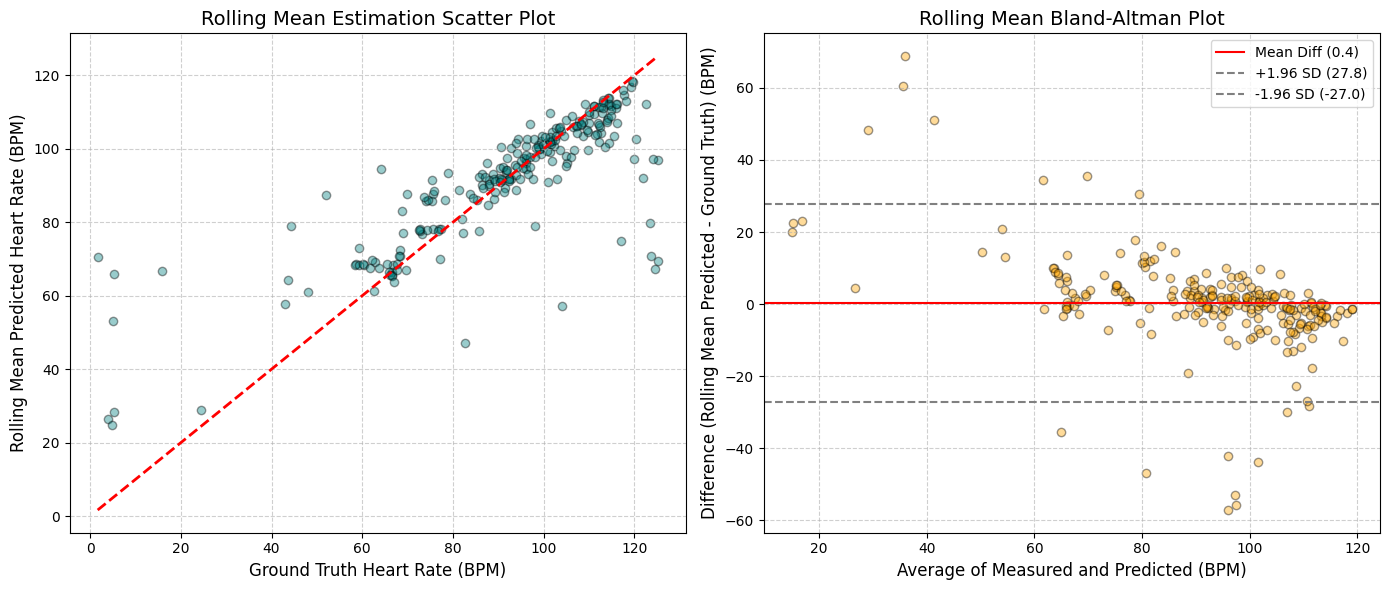

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. Generate rolling mean smoothed predictions for all subjects
smoothed_y_true = []
smoothed_y_pred = []

for sid, (y_true, y_pred) in predictions_dict.items():
    # Apply rolling mean smoothing with window_size=3
    y_pred_series = pd.Series(y_pred)
    y_pred_smoothed = y_pred_series.rolling(window=3, min_periods=1, center=True).mean().to_numpy()

    smoothed_y_true.extend(y_true)
    smoothed_y_pred.extend(y_pred_smoothed)

smoothed_y_true = np.array(smoothed_y_true)
smoothed_y_pred = np.array(smoothed_y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Scatter Plot with Rolling Mean Predictions
axes[0].scatter(smoothed_y_true, smoothed_y_pred, alpha=0.4, color='teal', edgecolors='k')
axes[0].plot([smoothed_y_true.min(), smoothed_y_true.max()], [smoothed_y_true.min(), smoothed_y_true.max()], 'r--', lw=2)
axes[0].set_xlabel('Ground Truth Heart Rate (BPM)', fontsize=12)
axes[0].set_ylabel('Rolling Mean Predicted Heart Rate (BPM)', fontsize=12)
axes[0].set_title('Rolling Mean Estimation Scatter Plot', fontsize=14)
axes[0].grid(True, linestyle='--', alpha=0.6)

# 2. Bland-Altman Plot with Rolling Mean Predictions
mean_val = (smoothed_y_true + smoothed_y_pred) / 2.0
diff_val = smoothed_y_pred - smoothed_y_true
mean_diff = np.mean(diff_val)
sd_diff = np.std(diff_val)

axes[1].scatter(mean_val, diff_val, alpha=0.4, color='orange', edgecolors='k')
axes[1].axhline(mean_diff, color='red', linestyle='-', label=f'Mean Diff ({mean_diff:.1f})')
axes[1].axhline(mean_diff + 1.96 * sd_diff, color='gray', linestyle='--', label=f'+1.96 SD ({mean_diff + 1.96*sd_diff:.1f})')
axes[1].axhline(mean_diff - 1.96 * sd_diff, color='gray', linestyle='--', label=f'-1.96 SD ({mean_diff - 1.96*sd_diff:.1f})')
axes[1].set_xlabel('Average of Measured and Predicted (BPM)', fontsize=12)
axes[1].set_ylabel('Difference (Rolling Mean Predicted - Ground Truth) (BPM)', fontsize=12)
axes[1].set_title('Rolling Mean Bland-Altman Plot', fontsize=14)
axes[1].legend(loc='upper right')
axes[1].grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()